#Instancia de evaluación:

Esta tarea nos permitirá no solo poner a prueba nuestras habilidades en la construcción de modelos, sino también comprender cómo diferentes enfoques de aprendizaje automático pueden tener un impacto significativo en los resultados.

# Para KNN

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
import seaborn as sns

In [55]:
# Preparación y Organización de Datos
# Cargar Dataset y mostrar primeras 5 filas
url = '/content/drive/MyDrive/Aprendizaje Automático/Archivos semana 4/student-mat.csv'
df = pd.read_csv(url, sep=";")

# Seleccionar variables para predecir nota final
# Variable Objetivo: G3 (Nota final)
# Variables Predictoras: age, studytime, failures, absences, G1, G2
# Para este modelo simple, elegiremos variables numéricas directas
features = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2']
X = df[features]
y = df['G3']

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [56]:
# Exploración Inicial (EDA)
print("\nInformación del DataFrame:")
df.info()
df.isnull().sum()


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-nu

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [57]:
print("\nDescripción del DataFrame:")
print(df.describe())


Descripción del DataFrame:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   

Para este trabajo, vuelvo a seleccionar el Dataset 'student-mat.csv'. La intención es poder aplicar dos nuevos modelos y poder comparar con los ya resueltos en la clase 4.

El dataset incluye 395 registros con variables como edad, tiempo de estudio, ausencias, apoyo familiar, consumo de alcohol, notas parciales y nota final.

No contiene valores nulos ni faltantes.



---

Mi objetivo es aplicar un modelo de aprendizaje automático para clasificar el rendimiento de estudiantes en tres categorías: Bajo, Medio y Alto.


---
En este caso, voy a utilizar los algoritmos de Arbol de Decisión, que me permite tomar decisiones lógicas basadas en características específicas. Y KNN, que me permite identificar patrones cercanos en conjuntos de datos, es valioso para la clasificación y la regresión.

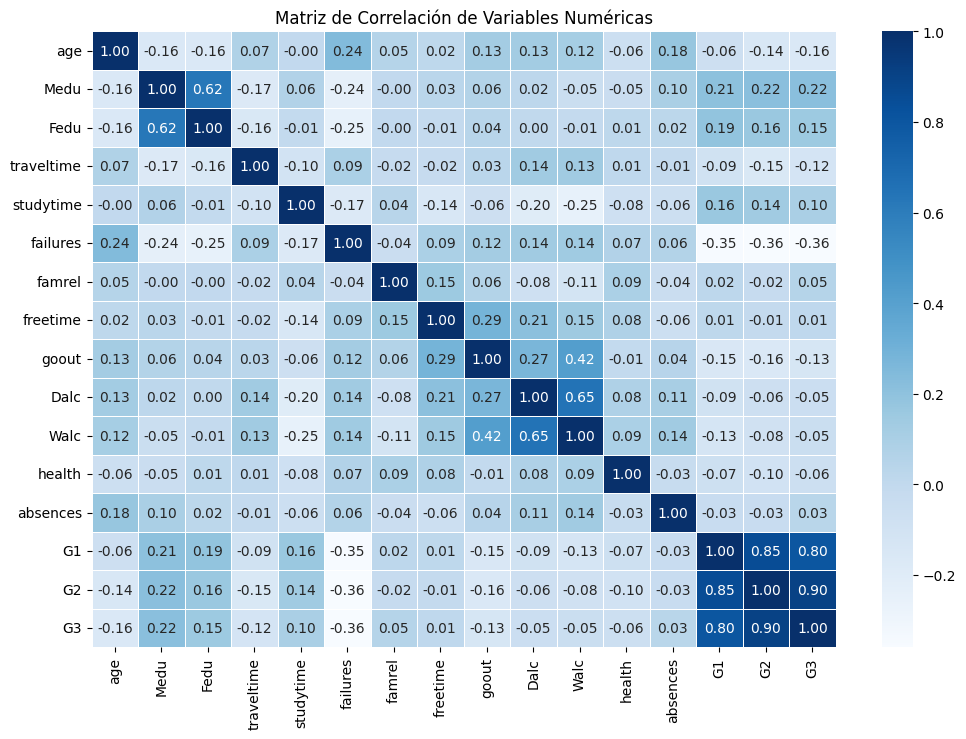

In [58]:
# 2. Matriz de Correlación
plt.figure(figsize=(12, 8))
# Seleccionamos solo columnas numéricas
df_numeric = df.select_dtypes(include=['number'])
correlation = df_numeric.corr()

sns.heatmap(correlation, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [59]:
# Selección de variables predictoras
features = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2']
X = df[features]
y = df['G3']

In [60]:
# Crear la variable 'Rendimiento', segun la nota final (G3) en categorías.

def clasificar_rendimiento(nota):
    if nota < 10:
        return 'Bajo'
    elif nota < 15:
        return 'Medio'
    else:
        return 'Alto'

df['Rendimiento'] = df['G3'].apply(clasificar_rendimiento)

# Ver distribución
print(df['Rendimiento'].value_counts())

Rendimiento
Medio    192
Bajo     130
Alto      73
Name: count, dtype: int64


In [61]:
# Codificación de las variables categóricas
# (Creo una copia para no mofificar el original)
df_encoded = df.copy()

label_encoder = LabelEncoder()

# Codificar automáticamente
for column in df_encoded.columns:

    if df_encoded[column].dtype == 'object':

        df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

In [62]:
# Ver resultado de codificación
df_encoded["Rendimiento"].head()


,Rendimiento
0,1
1,1
2,2
3,0
4,2


# División en Entrenamiento y Prueba

In [63]:
# Definimos el orden lógico manualmente
mapping = {'Bajo': 0, 'Medio': 1, 'Alto': 2}
df_encoded['Rendimiento'] = df['Rendimiento'].map(mapping)

# Difinir variables predictoras (X)
X = df_encoded[features]
X = df_encoded.drop(['G3', 'Rendimiento'], axis=1) #(Elimino G3)

# Definir variable objetivo: 'Rendimiento' (y)
y = df_encoded['Rendimiento']

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler() # Crear Escalador
X_train_scaled = scaler.fit_transform(X_train) # Escalar los datos de entrenamiento
X_test_scaled = scaler.transform(X_test) # Escalar los datos de prueba

# Modelo K-Nearest Neighbors (KNN)

In [64]:
# Crear modelo
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform') # (Todos los vecinos pesan igual, sin importar la distancia.)
# Entrenar
knn.fit(X_train_scaled, y_train)
# Predecir
y_pred_knn = knn.predict(X_test_scaled)

# Reporte de Clasificación con nombres reales
# Es importante que el orden en target_names coincida con 0, 1, 2
nombres_clases = ['Bajo', 'Medio', 'Alto']

print("Métricas KNN:")
print(classification_report(y_test, y_pred_knn, target_names=nombres_clases))
#

Métricas KNN:
              precision    recall  f1-score   support

        Bajo       0.67      0.52      0.58        27
       Medio       0.49      0.78      0.60        32
        Alto       1.00      0.35      0.52        20

    accuracy                           0.58        79
   macro avg       0.72      0.55      0.57        79
weighted avg       0.68      0.58      0.57        79



*Importante:*

**Acurrancy**: Porcentaje de predicciones correctas.

**Precisión**: Que tan correctas son las precisiones.

**Recall**: Cuántos casos reales detectó.

**F1-score**: Equilibrio entre Precisión y Recall.

#Análisis de Resultados

Obtener un 'Acurrancy' de 58 % me dice que mi modelo logró clasificar correctamente unos 6 de cada de 10 estudiantes (aprox).

Si voy por categoría, el modelo tuvo una precisión perfecta (1) en rendimiento 'Alto' (2), esto significa que siempre acertó. Aunque el Recall fue bajo (0.35), lo que indica que solo el 35 % de los datos, pertenecían realmente a esta categoría. (Podría ser que muchos casos se hayan confundido en otras clases).

Para el rendimiento 'Medio', el modelo muestra un 49% de predicciones correctas (Precisión). .estudiantes fueron clasificados en esta categoría, aunque no pertenecen. En cambio obtuvo el mejor Recall, detectando correctamente el 78% de los estudiantes pertenecen realmente a esta categoría.

En rendimiento 'Bajo', el modelo obtuvo una Precisión de 0.67, que me indica que poco mas de la mitad de los estudiantes estan clasificados correctamente en esta categoría. Y un Recall de 0.52, lo que nos indica que la mitad de los casos son reales.

# Matriz de Confusión

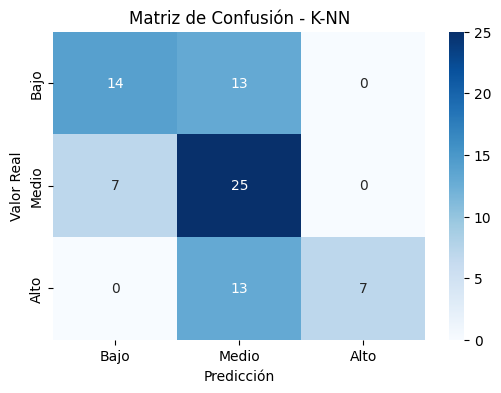

In [65]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bajo', 'Medio', 'Alto'],
    yticklabels=['Bajo', 'Medio', 'Alto']
)

plt.title('Matriz de Confusión - K-NN')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

*Importante*

La matriz de confusión permite analizar cómo se comportó el modelo K-NN al clasificar el rendimiento académico de los estudiantes en las categorías:

-Bajo

-Medio

-Alto

En la matriz:

-las filas representan los valores reales,

-las columnas representan las predicciones realizadas por el modelo.

Los valores ubicados en la diagonal principal representan las clasificaciones correctas.


#Interpretación de Matriz

El modelo logró identificar correctamente 25 de los estudiantes con **'Medio'** rendimiento. Y solo 7 mal clasificados (Bajo).

La categoría '**Bajo**' obtubo solo 14 estudiantes correctamente clasificados, y 13 estudiantes clasificados como rendimiento Medio. Esto indica que el modelo tuvo un rendimiento intermedio.

Para la categoría '**Alto**', solo 7 estudiantes fueron clasificados correctamente, y 13 clasificados incorrectamente como 'Medio'. Esto nos muestra que el rendimiento en esta categoría tuvo dificultades.


#Fronteras de Decisión

Sirve para entender como clasifica el modelo, qué regiones considera (Bajo, Medio, Alto) y como influyen las variables elegidas, en este caso utilizo G1 (notas del primer período) y G2 (notas del segundo período).


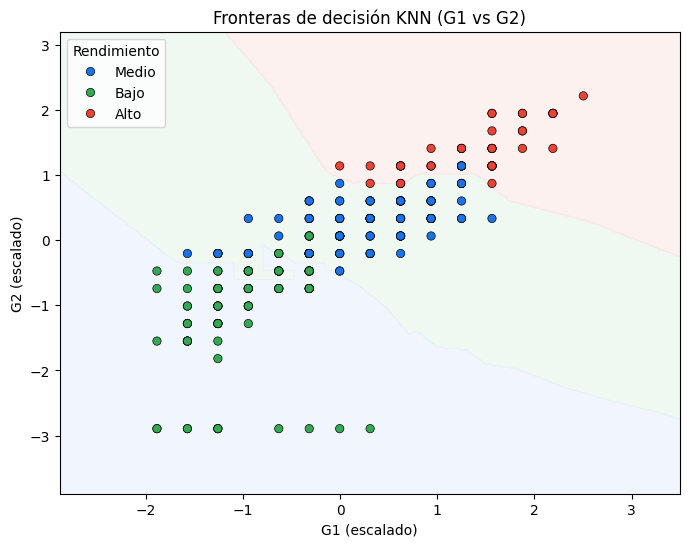

In [66]:
# Visualización en 2D del modelo KNN usando 'G1' y 'G2'

# Seleccionamos solo dos variables
X_simple2 = df[["G1", "G2"]]
y_simple2 = df["Rendimiento"]

# División en entrenamiento y prueba
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_simple2, y_simple2, test_size=0.3, random_state=42
)

# Escalamos los datos
scaler = StandardScaler()
X_train_s2_scaled = scaler.fit_transform(X_train_s2)
X_test_s2_scaled = scaler.transform(X_test_s2)

# Entrenamos el modelo KNN
knn_simple2 = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn_simple2.fit(X_train_s2_scaled, y_train_s2)

# Definimos malla (meshgrid)
h = .02
x_min, x_max = X_train_s2_scaled[:, 0].min() - 1, X_train_s2_scaled[:, 0].max() + 1
y_min, y_max = X_train_s2_scaled[:, 1].min() - 1, X_train_s2_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predicciones para cada punto de la malla
Z = knn_simple2.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert string labels to numerical values for plotting
label_map = {"Bajo": 0, "Medio": 1, "Alto": 2}
Z = np.array([label_map[label] for label in Z])

Z = Z.reshape(xx.shape)


# Colores
cmap_light = ListedColormap([
    "#E8F0FE",
    "#E6F4EA",
    "#FCE8E6"
    ])
cmap_bold = [
    "#1A73E8",
    "#34A853",
    "#EA4335"
    ]

# Gráfico
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
sns.scatterplot(
    x=X_train_s2_scaled[:, 0],
    y=X_train_s2_scaled[:, 1],
    hue=y_train_s2,
    palette=cmap_bold,
    edgecolor="k"
)
plt.title("Fronteras de decisión KNN (G1 vs G2)")
plt.xlabel("G1 (escalado)")
plt.ylabel("G2 (escalado)")
plt.show()

*Importante*:

*En el gráfico, los valores de las variables escaladas que aparecen en negativo, significa que estan 'debajo de la media'*

El gráfico muestra una visualización bidimensional del modelo K-NN utilizando las variables:

G1 → nota del primer período

G2 → nota del segundo período

Cada punto representa un estudiante y el color indica su categoría de rendimiento académico:

Verde → Bajo

Azul → Medio

Rojo → Alto

Además, el fondo coloreado representa las regiones de decisión generadas por el algoritmo K-NN, es decir, las zonas donde el modelo clasifica nuevos estudiantes según sus características.

#Interpretación del gráfico de Fronteras de decisión

Se observa como el algoritmo separa las distintas categorías de rendimiento según la cercanía entre estudiantes. Las regiones coloreadas representan las áreas de clasificación generadas por el modelo, mientras que los puntos corresponden a observaciones reales del dataset.

Los estudiantes de rendimiento 'Bajo' se concentran principalmente en la zona inferior izquierda del gráfico, donde los valores escalados de G1 y G2 son menores.

Los estudiantes de rendimiento 'Medio' aparecen ubicados en la zona central del gráfico.

Los estudiantes de rendimiento 'Alto' se concentran en la parte superior derecha del gráfico, donde las notas G1 y G2 son más elevadas.